# Visualization Generation for Department Showcase
To ensure a consistent style and a good look, I am redoing select graphs and plots. I am also trying to mkae the work slightly more contiguous, and so might make some changes to the experiments as I go. 

I will try and save all plots in an adjacent directory `presentation_plots`

### Visualization Contents
1. Data Exploration: visualizing base dataset with a few important plots
2. Dataset Definition: A few select plots like
   - Requested features with colored outliers
   - Density plots for output current in different runs
3. Modelling Data:
    -  Comparison of NN and RF on various split options to justify RF choice
4. Experiments
    - Which feature group performed best, RF
    - MinMax Scaling results
    - Set # prediction, Binary final accuracies and Full set accuracies, as well as some enlightening feature importances
    - Results of filtering by different STD thresholds on requested values, side by sides
    - Deeper Examination of an outlier point in the unaccumulated data

In [42]:
# Imports
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import imageio
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import sys
import os
sys.path.append(os.path.abspath('..'))
from venus_ml import VenusDataset

### Dataset Information

In [43]:
requested_dict = {
    'k18_fw_mean': [1.4e3, 'Watts'],
    'g28_fw_mean': [4.3e3, 'Watts'],
    'inj_i_mean': [185, 'Amps'],
    'ext_i_mean': [137, 'Amps'],
    'mid_i_mean': [153, 'Amps'],
    'sext_i_mean': [430, 'Amps'],
    'extraction_v_mean': [20, 'kV'],
    'puller_v_mean': [2, 'kV'],
}

requested_features = list(requested_dict.keys())

feature_groups = {
    "S": ["inj_mbar", "bias_v", "bias_i", "extraction_i"],
    "M": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "L": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"],
}

def get_features(names, mean=True, std=False):
    out_list = []
    for name in names:
        if mean:
            out_list.append(name + "_mean")
        if std:
            out_list.append(name + "_std")
    return out_list

### Helper Split Functions

In [44]:
def one_run(data, run):
    train, val = data.generate_splits((run,))  
    trainX, trainY = train.to_numpy()
    valX, valY = val.to_numpy()
    return trainX, trainY, valX, valY

def both_runs(data, run1, run2):
    train, val = data.generate_splits((run1, run2))  
    trainX, trainY = train.to_numpy()
    valX, valY = val.to_numpy()
    return trainX, trainY, valX, valY

def between_runs(data, run1, run2):
    data = data.get_runs((run1,run2))
    return data[run1][0], data[run1][1], data[run2][0], data[run2][1] # train_x, train_y, validation_x, validation_y

def all_splits(data, run1, run2):
    return {
        "one" : one_run(data, run1),
        "both" : both_runs(data, run1, run2),
        "between": between_runs(data, run1, run2)
    }

### Helper Plotting Functions

In [45]:
def scatter(df, feature_x, feature_y, feature_color=None, title="Scatter Plot", xlabel=None, ylabel=None, c_label=None, save_image=False):
    plt.style.use('dark_background')  # Set dark background
    
    # Create the figure and axis
    plt.figure(figsize=(10, 6))
    
    # Handle scatter plot with a color map
    if feature_color:
        scatter = plt.scatter(df[feature_x], df[feature_y], c=df[feature_color], cmap='coolwarm', edgecolor=None)
        
        # Create a color bar
        cbar = plt.colorbar(scatter)
        
        # Set the color bar label and scientific notation format
        cbar.set_label(c_label if c_label else feature_color, fontsize=12)
        cbar.formatter = mpl.ticker.ScalarFormatter(useMathText=True)  # Enable scientific notation
        cbar.formatter.set_powerlimits((-2, 2))  # Set limits for when to switch to scientific notation
        cbar.update_ticks()
    else:
        sns.scatterplot(data=df, x=feature_x, y=feature_y, color='skyblue', edgecolor=None)

    # Set plot labels (use custom labels if provided)
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel if xlabel else feature_x, fontsize=12)  # Custom label or fallback to feature_x
    plt.ylabel(ylabel if ylabel else feature_y, fontsize=12)  # Custom label or fallback to feature_y
    
    # Adjust layout
    plt.ylim(0.7e-7, 2.5e-7) 
    plt.tight_layout()

    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()

def scatter_multiple_runs(df, run_ids, feature_x, feature_y, title="Scatter Plot", xlabel=None, ylabel=None, save_image=False):
    plt.style.use('dark_background')  # Set dark background
    
    # Create the figure and axis
    plt.figure(figsize=(10, 6))
    
    # Generate a list of colors
    colors = plt.cm.rainbow(np.linspace(0, 1, len(run_ids)))
    
    # Plot each run_id with a different color
    for color, run_id in zip(colors, run_ids):
        run_df = df[df.run_id == run_id]
        plt.scatter(run_df[feature_x], run_df[feature_y], color=color, label=f"Set {run_id}", s=7)
    
    # Set plot labels (use custom labels if provided)
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel if xlabel else feature_x, fontsize=12)  # Custom label or fallback to feature_x
    plt.ylabel(ylabel if ylabel else feature_y, fontsize=12)  # Custom label or fallback to feature_y
    
    # Add legend
    plt.legend(title='Set #s')
    
    # Adjust layout
    # plt.ylim(-1, 20) 
    plt.tight_layout()

    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
def time_scatter(df, feature_y, title="Time Series Scatter", color_outliers=False, std_threshold=2, save_image=False): 
    plt.style.use('dark_background')  # Set dark background
    time_col = 'unix_time' if 'unix_time' in df.columns else 'time'
    
    plt.figure(figsize=(10, 6))
    
    if color_outliers:
        mean = df[feature_y].mean()
        std_dev = df[feature_y].std()
        outliers = np.abs(df[feature_y] - mean) > (std_threshold * std_dev)
        sns.scatterplot(data=df[~outliers], x=time_col, y=feature_y, color='skyblue', label='Inliers')
        sns.scatterplot(data=df[outliers], x=time_col, y=feature_y, color='red', label='Outliers')
    else:
        sns.scatterplot(data=df, x=time_col, y=feature_y, color='skyblue')
    
    plt.title(title, fontsize=14)
    plt.xlabel(time_col, fontsize=12)
    plt.ylabel(feature_y, fontsize=12)
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300)
    
    plt.show()
    
def density_plot(df, feature, title="Density Plot", save_image=False):
    plt.style.use('dark_background')  # Set dark background
    plt.figure(figsize=(10, 6))
    
    # Multiply the feature data by 1e6 to convert to microamps
    data_in_microamps = df[feature] * 1e6
    
    # Plot the density plot with the converted data
    sns.kdeplot(data_in_microamps, fill=True, color='skyblue', bw_adjust=0.5)
    
    plt.title(title, fontsize=14)
    # Set the x-axis label to the specified format
    plt.xlabel(r'O$^{7+}$ [$\mu$A]', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300)
    
    plt.show()

    
def run_id_status_barplot(df, run_id_col='run_id', status_col='status', title="Run ID vs Status Bar Plot", save_image=False):
    
    plt.style.use('dark_background')  # Set dark background
    
    # Group the data by run_id and status, then count the occurrences of each status per run_id
    grouped_data = df.groupby([run_id_col, status_col]).size().reset_index(name='counts')
    
    # Pivot the data to get a 'run_id' by 'status' table with counts
    pivot_table = grouped_data.pivot(index=run_id_col, columns=status_col, values='counts').fillna(0)
    
    # Plot the stacked bar chart
    pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
    
    # Add title and labels
    plt.title(title, fontsize=14)
    plt.xlabel(run_id_col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # Add a legend with the status values
    plt.legend(title=status_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()

    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
def run_id_status_normalized_barplot(df, run_id_col='run_id', status_col='status', title="Run ID vs Status Proportions", 
                                     exclude_run_id="08", save_image=False):
    
    """
    Create a normalized bar plot where each bar represents a unique run_id, and each bar is split by the unique values in the status column.
    The size of the bars is normalized, so that each bar sums to 1 (proportion of each status per run_id).
    
    Parameters:
    df: DataFrame
        The dataframe containing the data.
    run_id_col: str
        The name of the column representing the run_id.
    status_col: str
        The name of the column representing the status (which will be split into different colors per bar).
    title: str
        Title of the plot.
    exclude_run_id: str
        The run_id to be excluded from the plot.
    save_image: bool
        If True, saves the plot as a PNG image in the 'presentation_plots' directory.
    """
    
    plt.style.use('dark_background')  # Set dark background
    
    # Filter out the specific run_id to be excluded
    df_filtered = df[df[run_id_col] != exclude_run_id]
    
    # Group the data by run_id and status, then count the occurrences of each status per run_id
    grouped_data = df_filtered.groupby([run_id_col, status_col]).size().reset_index(name='counts')
    
    # Pivot the data to get a 'run_id' by 'status' table with counts
    pivot_table = grouped_data.pivot(index=run_id_col, columns=status_col, values='counts').fillna(0)
    
    # Normalize the counts by dividing by the sum for each run_id (row-wise)
    normalized_pivot_table = pivot_table.div(pivot_table.sum(axis=1), axis=0)
    
    # Plot the stacked bar chart with normalized proportions
    normalized_pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
    
    # Add title and labels
    plt.title(title, fontsize=14)
    plt.xlabel(run_id_col, fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    
    # Add a legend with the status values
    plt.legend(title=status_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()

    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()
def compare_density_plots(df, feature, run_id_1, run_id_2, run_id_col='run_id', title="Density Plot Comparison", save_image=False):
    
    plt.style.use('dark_background')  # Set dark background
    
    # Filter the dataframe for the two selected run_ids
    df_run_1 = df[df[run_id_col] == run_id_1]
    df_run_2 = df[df[run_id_col] == run_id_2]
    
    data_in_microamps1 = df_run_1[feature] * 1e6
    data_in_microamps2 = df_run_2[feature] * 1e6
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot density for the first run_id
    sns.kdeplot(data_in_microamps1, fill=True, label=f'Run {run_id_1}', color='skyblue', bw_adjust=0.5)
    
    # Plot density for the second run_id
    sns.kdeplot(data_in_microamps2, fill=True, label=f'Run {run_id_2}', color='orange', bw_adjust=0.5)
    
    # Add title and labels
    plt.title(title, fontsize=14)
    plt.xlabel(r'O$^{7+}$ [$\mu$A]', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    # Add legend
    # plt.legend(loc='best')
    
    plt.tight_layout()

    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
def compare_scaled_density_plots(df, feature, run_id_1, run_id_2, run_id_col='run_id', title="Scaled Density Plot Comparison", save_image=False):
    
    plt.style.use('dark_background')  # Set dark background
    
    # Filter the dataframe for the two selected run_ids
    df_run_1 = df[df[run_id_col] == run_id_1]
    df_run_2 = df[df[run_id_col] == run_id_2]
    
    # Combine the two runs to ensure consistent scaling
    combined_data = pd.concat([df_run_1, df_run_2])
    
    # Apply min-max scaling
    scaler = StandardScaler()
    combined_data[[feature]] = scaler.fit_transform(combined_data[[feature]])
    
    # Split back into the original runs after scaling
    df_run_1_scaled = combined_data[combined_data[run_id_col] == run_id_1]
    df_run_2_scaled = combined_data[combined_data[run_id_col] == run_id_2]
    
    data_in_microamps1 = df_run_1_scaled[feature] * 1e6
    data_in_microamps2 = df_run_2_scaled[feature] * 1e6
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot density for the first run_id
    sns.kdeplot(data_in_microamps1, fill=True, label=f'Run {run_id_1}', color='skyblue', bw_adjust=0.5)
    
    # Plot density for the second run_id
    sns.kdeplot(data_in_microamps2, fill=True, label=f'Run {run_id_2}', color='orange', bw_adjust=0.5)
    
    # Add title and labels
    plt.title(title, fontsize=14)
    plt.xlabel(f'{feature} (Scaled)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    # Add legend
    # plt.legend(loc='best')
    
    plt.tight_layout()

    # Save plot if requested
    if save_image:
        output_dir = "presentation_plots"
        os.makedirs(output_dir, exist_ok=True)
        file_path = os.path.join(output_dir, f"{title.replace(' ', '_').lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()

## Full Datasets

In [46]:
raw_config = {
    "file_path": "../data/raw_watch_data.parquet",
    "input_columns": [],
    "output_columns": [],
}

acc_config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": [],
    "output_columns": [],
}

all_stabs_config = {
    "file_path": "../data/all_stabilties_settled_watch_data.parquet",
    "input_columns": [],
    "output_columns": [],
}

raw_dataset = VenusDataset(**raw_config)
acc_dataset = VenusDataset(**acc_config)
all_stabs_dataset = VenusDataset(**all_stabs_config)
print(list(acc_dataset.df.columns).index("bias_i_mean"))

29



## Data Exploration

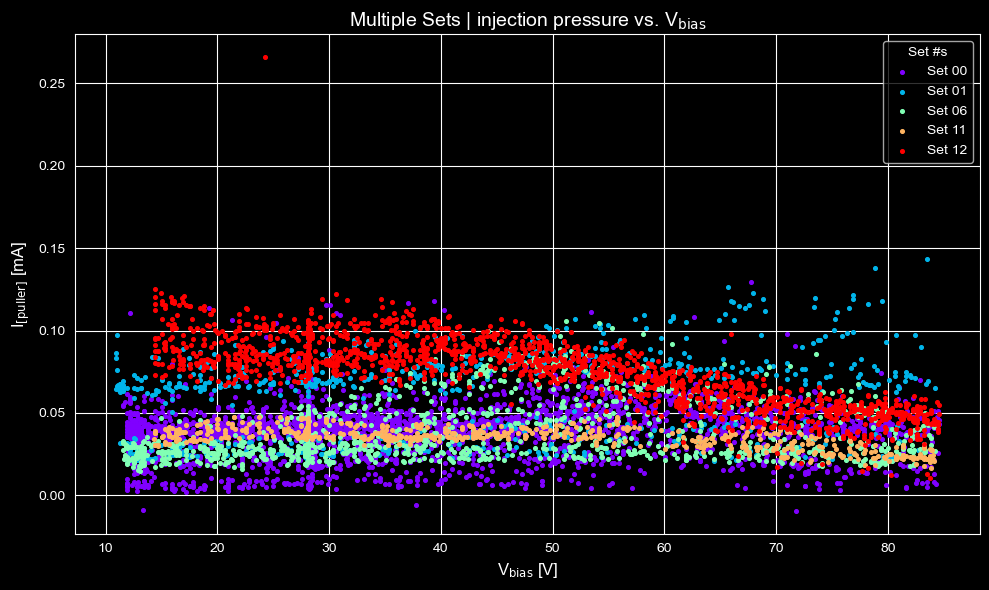

In [47]:
df = acc_dataset.df

scatter_multiple_runs(df, [ "00", "01", "06", "11", "12"], "bias_v_mean","puller_i_mean",  title=r"Multiple Sets | injection pressure vs. V$_\mathrm{bias}$", xlabel=r'V$_\mathrm{bias}$ [V]', ylabel=r'I$_\mathrm{[puller]}$ [mA]', save_image=True )

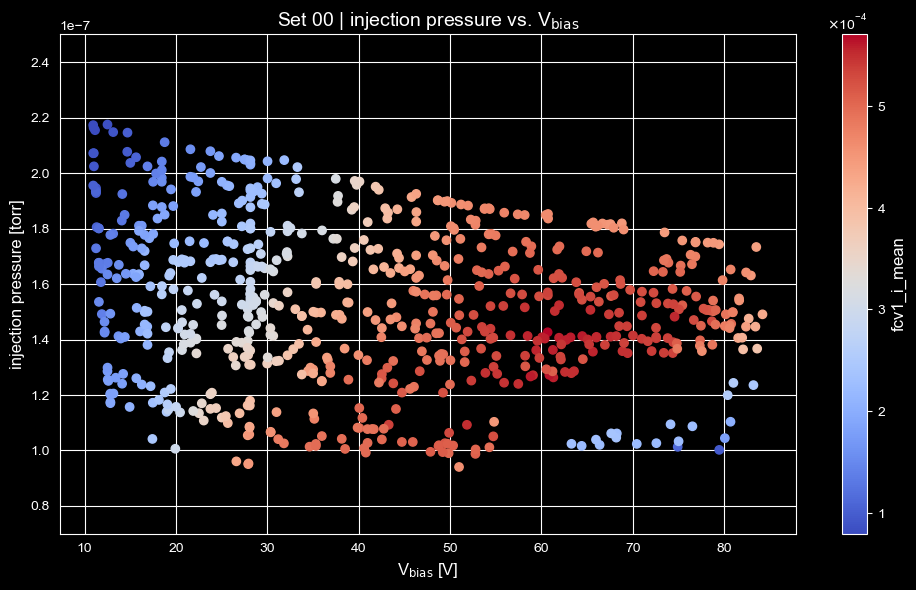

In [48]:
df = acc_dataset.df[acc_dataset.df.run_id == "01"]
feature1 = "bias_v_mean"
feature2 = "inj_mbar_mean"
hue = "fcv1_i_mean"
scatter(df, feature1, feature2, hue, title=r"Set 00 | injection pressure vs. V$_\mathrm{bias}$", xlabel=r'V$_\mathrm{bias}$ [V]', ylabel=r'injection pressure [torr]', save_image=False)

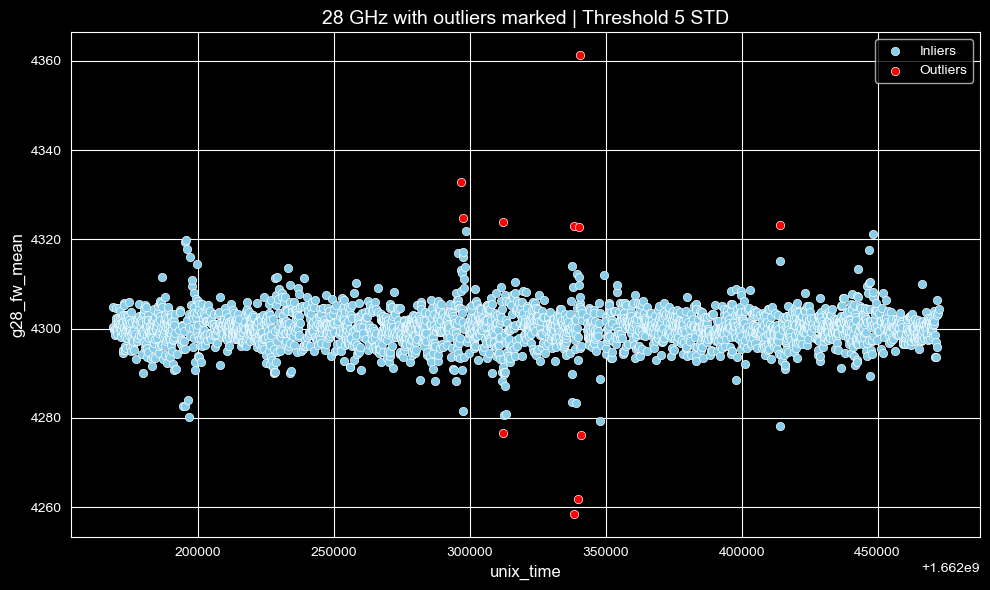

In [49]:
df = acc_dataset.df[acc_dataset.df.run_id == "00"]
time_scatter(df, "g28_fw_mean", title="28 GHz with outliers marked | Threshold 5 STD", color_outliers=True, std_threshold=5, save_image=True)

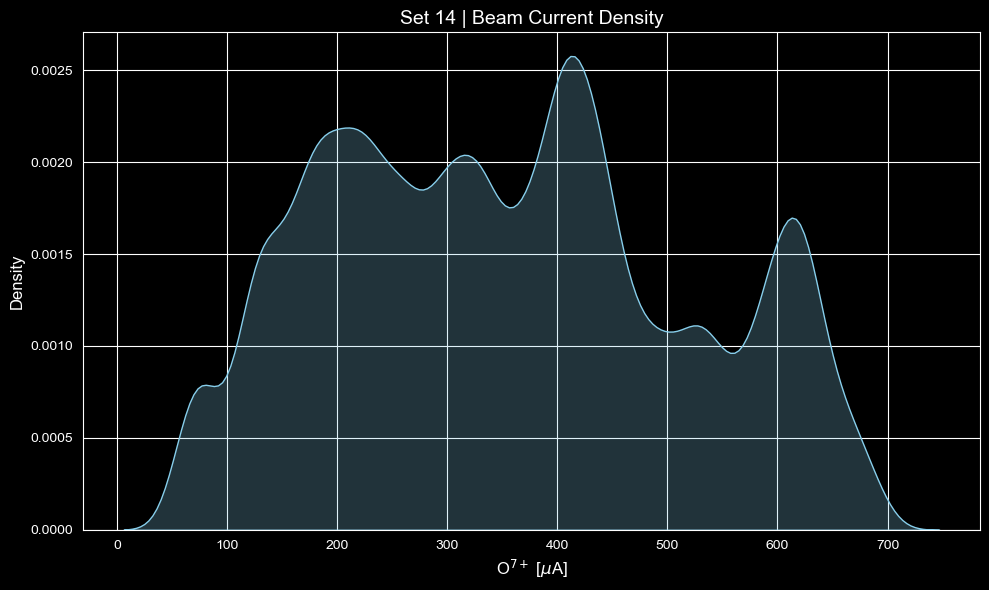

In [50]:
# df = acc_dataset.df
df = acc_dataset.df[acc_dataset.df.run_id == "14"]
density_plot(df, "fcv1_i_mean", title="Set 14 | Beam Current Density", save_image=True)

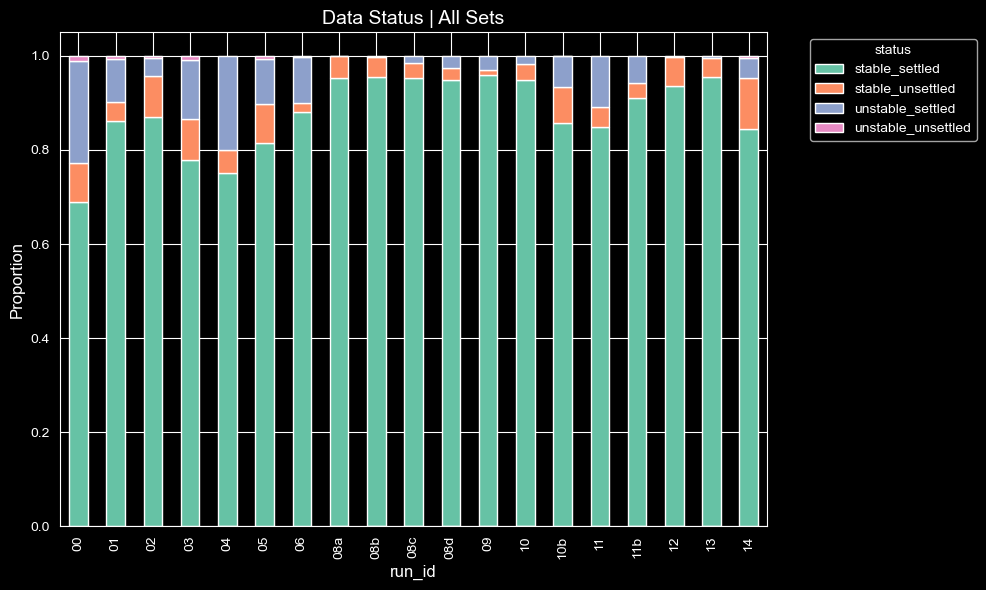

In [51]:
df = all_stabs_dataset.df
run_id_status_normalized_barplot(df, title="Data Status | All Sets", save_image=False)

## Dataset Definition

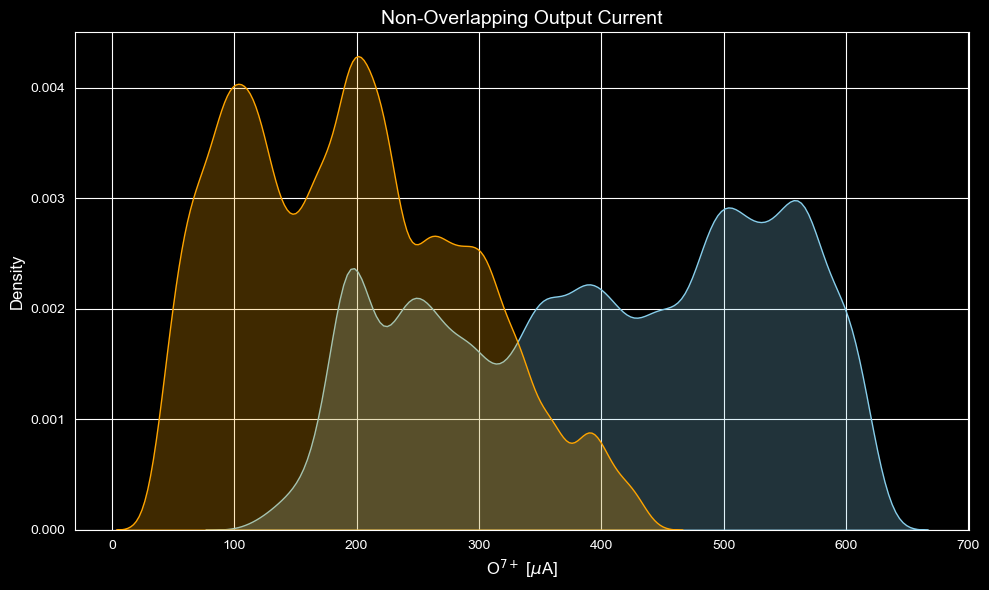

In [52]:
compare_density_plots(df, "fcv1_i_mean", "00", "02",title="Non-Overlapping Output Current", save_image=True)

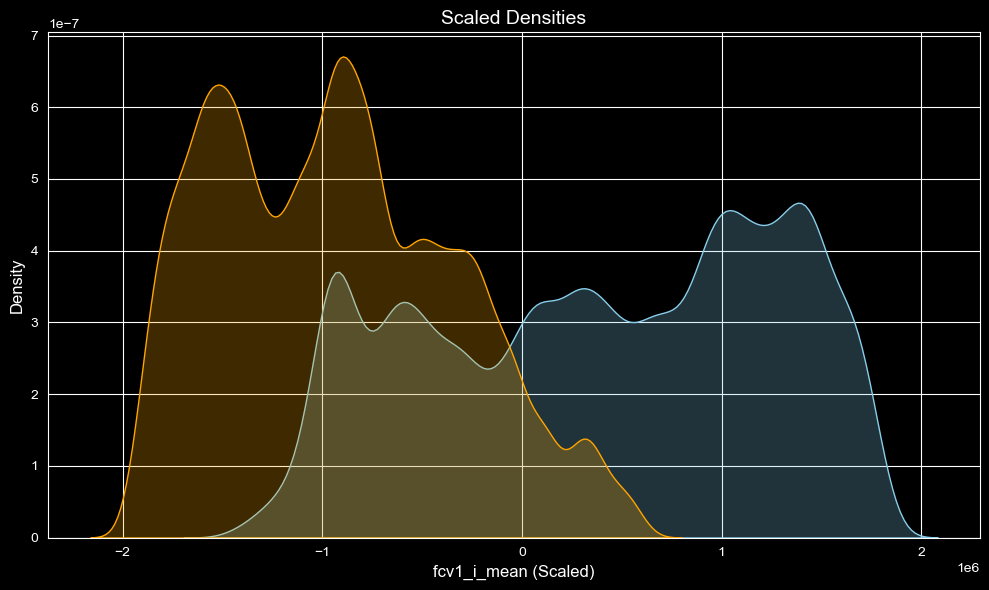

In [53]:
compare_scaled_density_plots(df, "fcv1_i_mean", "00", "02",title="Scaled Densities", save_image=False)

## Experiments

### Deciding on a Feature Group

In [54]:
feature_groups = {
    "S": ["inj_mbar", "bias_v", "bias_i", "extraction_i"],
    "M": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "L": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"],
}

data_set_config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": [],
    "output_columns": ["fcv1_i_mean"],
}
datasets = {}

for feature_group in feature_groups.keys():
    data_set_config["input_columns"] = get_features(feature_groups[feature_group], std=False)
    datasets[feature_group] = VenusDataset(**data_set_config)
print([dataset.df.shape for dataset in datasets.values()])

[(29290, 170), (29290, 170), (29290, 170)]


In [55]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

results = {}
for i in range(1):
    print(i)
    for group, dataset in datasets.items():
        results[group] = {}
        for split, data in all_splits(dataset, "00", "14").items():
            train_x, train_y, test_x, test_y = data
            if split == 'between':
                train_y, test_y = train_y.to_numpy(), test_y.to_numpy()
        
            train_y, test_y = train_y.ravel(), test_y.ravel()
            rf = RandomForestRegressor(n_estimators=100, n_jobs=-1)
            rf.fit(train_x, train_y)
            
            test_preds_rf = rf.predict(test_x)
            if split in results[group]:
                results[group][split] += mean_squared_error(test_y, test_preds_rf)/200
            else:
                results[group][split] = mean_squared_error(test_y, test_preds_rf)/200
        

0


/var/folders/vn/l4f760sx4jdgqk03q9yr5c2h0000gn/T/ipykernel_27205/4244604924.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(groups)).colors


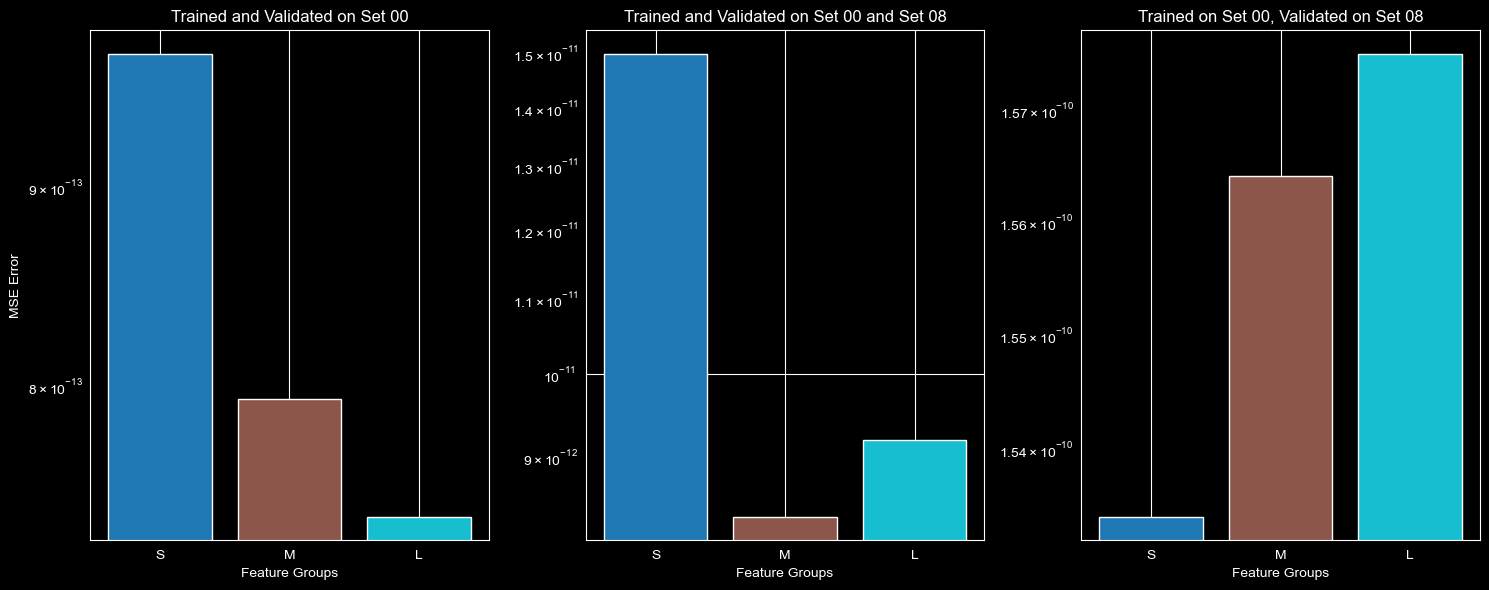

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def plot_group_split_bars(data_dict):
    """
    Generates bar plots for each split comparing groups, displayed horizontally on different subplots in the same figure.
    
    Parameters:
    data_dict: dict
        Dictionary where keys are 'groups' and values are dictionaries of 'splits' and their corresponding values.
    """
    # Get the list of splits from the first group (assuming all groups have the same splits)
    splits = list(next(iter(data_dict.values())).keys())
    groups = list(data_dict.keys())

    # Define a color palette (you can adjust the colors or use a different colormap)
    colors = plt.cm.get_cmap('tab10', len(groups)).colors

    # Create a figure with a subplot for each split, aligned horizontally
    fig, axes = plt.subplots(1, len(splits), figsize=(15, 6), sharey=False)
    
    # If there's only one split, make sure `axes` is iterable
    if len(splits) == 1:
        axes = [axes]
    
    # Loop through each split and generate a bar chart in a separate subplot
    for i, split in enumerate(splits):
        ax = axes[i]  # Select the subplot
        values = [data_dict[group][split] for group in groups]  # Collect the values for each group for the current split
        bar_positions = np.arange(len(groups))
        
        # Create the bar plot for the current split with different colors
        ax.bar(bar_positions, values, color=colors[:len(groups)], tick_label=groups)

        # Set the title and labels
        if split == 'between':
            ax.set_title(f'Trained on Set 00, Validated on Set 08')
        elif split == 'one':
            ax.set_title(f'Trained and Validated on Set 00')
        else:
            ax.set_title(f'Trained and Validated on Set 00 and Set 08')
        ax.set_xlabel('Feature Groups')
        ax.set_yscale("log")
        if i == 0:
            ax.set_ylabel('MSE Error')

    # Adjust layout to make sure labels and titles fit
    plt.tight_layout()
    plt.savefig("presentation_plots/group_split_bars.png")
    plt.show()

 
plot_group_split_bars(results)

 ## Testing Min-Max Scaling on Beam Current

In [57]:
from sklearn.metrics import r2_score

scaled_config = {
    "file_path": "../data/minmax_watch_data.parquet",
    "input_columns": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "output_columns": ["fcv1_i_mean"],
}

config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "output_columns": ["fcv1_i_mean"],
}

scaled = VenusDataset(**scaled_config)
unscaled = VenusDataset(**config)

s_trainX, s_trainY, s_valX, s_valY = between_runs(scaled, "00", "09")
trainX, trainY, valX, valY = between_runs(unscaled, "00", "09")

rf_scaled = RandomForestRegressor(n_estimators=500, n_jobs=-1)
rf_unscaled = RandomForestRegressor(n_estimators=500, n_jobs=-1)

rf_scaled.fit(s_trainX, s_trainY)
rf_unscaled.fit(trainX, trainY)

scaled_pred = rf_scaled.predict(s_valX)
unscaled_pred = rf_unscaled.predict(valX)

scaled_score = r2_score(s_valY, scaled_pred)
unscaled_score = r2_score(valY, unscaled_pred)


/Users/ezraapple/miniforge3/envs/berkeley_lab/lib/python3.11/site-packages/sklearn/base.py:1351: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ezraapple/miniforge3/envs/berkeley_lab/lib/python3.11/site-packages/sklearn/base.py:1351: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [58]:
import matplotlib.pyplot as plt

def plot_scaled_unscaled_predictions(scaled_target, scaled_prediction, unscaled_target, unscaled_prediction, scaledR2, unscaledR2):
    """
    Plots scaled and unscaled target vs. predictions with corresponding R2 values as labels under each subplot.
    
    Parameters:
    - scaled_target: array-like, scaled target values
    - scaled_prediction: array-like, scaled prediction values
    - unscaled_target: array-like, unscaled target values
    - unscaled_prediction: array-like, unscaled prediction values
    - scaledR2: float, R2 value for scaled predictions
    - unscaledR2: float, R2 value for unscaled predictions
    """
    # Create the x-axis based on the length of the targets/predictions
    x_values = range(len(scaled_target))
    
    # Create a figure with 2 horizontal subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    indices = np.argsort(scaled_target)
    # Plot scaled targets and predictions on the first subplot
    axes[0].scatter(x_values, scaled_target[indices], label='Scaled Target', color='blue', alpha=0.5)
    axes[0].scatter(x_values, scaled_prediction[indices], label='Scaled Prediction', color='red', alpha=0.5)
    axes[0].set_title('Scaled Targets vs Predictions')
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Scaled Values')
    axes[0].legend()
    
    # Display the corresponding R2 value for the scaled plot
    axes[0].text(0.5, -0.15, f'R² (Scaled): {scaledR2:.4f}', ha='center', va='center', transform=axes[0].transAxes, fontsize=12)

    # Plot unscaled targets and predictions on the second subplot

    axes[1].scatter(x_values, unscaled_target[indices]*1e6, label='Unscaled Target', color='blue', alpha=0.5)
    axes[1].scatter(x_values, unscaled_prediction[indices]*1e6, label='Unscaled Prediction', color='red', alpha=0.5)
    axes[1].set_title('Unscaled Targets vs Predictions')
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel(r'O$^{7+}$ [$\mu$A]')
    # axes[1].legend()
    
    # Display the corresponding R2 value for the unscaled plot
    axes[1].text(0.5, -0.15, f'R² (Unscaled): {unscaledR2:.4f}', ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

    # Adjust layout to ensure everything fits well
    plt.tight_layout()
    
    # Display the figure
    plt.savefig("presentation_plots/scaled_unscaled_predictions.png")
    plt.show()


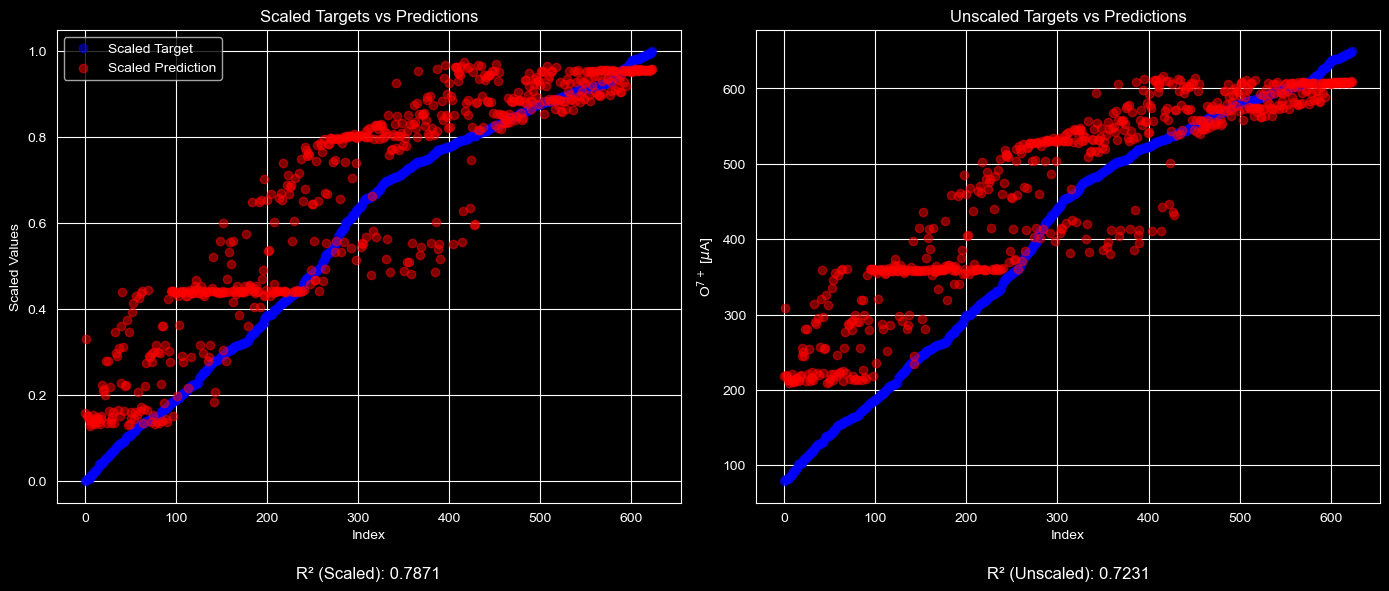

In [59]:
plot_scaled_unscaled_predictions(s_valY.to_numpy().squeeze(), scaled_pred.squeeze(), valY.to_numpy().squeeze(), unscaled_pred.squeeze(), scaled_score, unscaled_score)

## Predict Set #

In [60]:
data_set_config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": get_features(["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"], std=False),
    "output_columns": ["run_id"],
}
predict_run_data = VenusDataset(**data_set_config)

In [61]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier


import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

def train_and_evaluate(dataset):
    # Convert dataset to numpy arrays for inputs and outputs
    inputs, outputs = dataset.to_numpy()

    # Create the classifier
    clf = RandomForestClassifier(n_estimators=250, random_state=88, n_jobs=-1)
    clf.fit(inputs, outputs.ravel())  # Train using the entire dataset
    print(f"Training accuracy: {clf.score(inputs, outputs):.4f}")

    # Calculate feature importances directly from the trained model
    feature_importances = pd.DataFrame(
        clf.feature_importances_, 
        index=dataset.inputs.columns, 
        columns=['Feature Importance']
    )

    # Compute permutation importances on the same data used for training to evaluate robustness of features
    perm_importance = permutation_importance(
        clf, inputs, outputs, n_repeats=20, random_state=42, n_jobs=-1
    )
    perm_importance_df = pd.DataFrame(
        data=perm_importance.importances_mean, 
        index=dataset.inputs.columns, 
        columns=['Permutation Importance']
    )

    # Combine and sort the feature importances for visualization
    combined_importances = pd.concat([feature_importances, perm_importance_df], axis=1)
    combined_importances.sort_values(by='Feature Importance', ascending=False, inplace=True)

    # Select the top 8 features
    top_features = combined_importances.head(8)

    # Plot the combined importances as a horizontal bar chart
    ax = top_features.plot(kind='barh', figsize=(12, 8), colormap='viridis')
    plt.title('Top 8 Feature and Permutation Importances')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.gca().invert_yaxis()  # Invert the y-axis to have the most important features at the top

    # Adjust layout and save the plot
    plt.tight_layout()
    plt.savefig("presentation_plots/feature_importances.png")
    plt.show()



Training accuracy: 0.9436


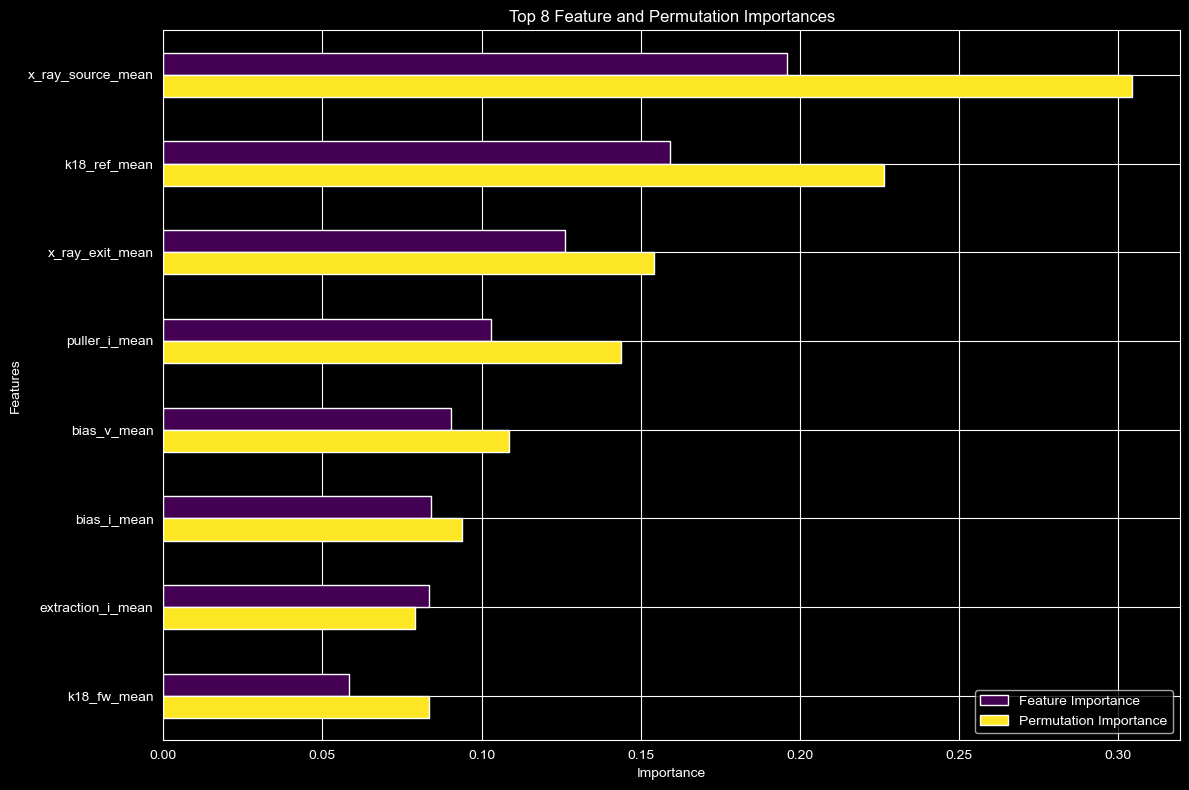

In [62]:
train_and_evaluate(predict_run_data)

## Larger Scale Regression

In [85]:
config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": ["inj_mbar_mean", "bias_v_mean", "bias_i_mean", "extraction_i_mean", "ext_mbar_mean", "k18_fw_mean", "k18_ref_mean", "g28_fw_mean", "puller_i_mean"],
    "output_columns": ["fcv1_i_mean"],
}

dataset = VenusDataset(**config)
train, val = dataset.generate_splits(("00", "01", "02", "03", "04", "05", "06", "08", "09", "10", "10b", "11", "11b", "12", "13", "14"), validation_size=0.9)
print(train)

In [86]:
trainX, trainY = train.to_numpy()
valX, valY = val.to_numpy()
print(trainX.shape, trainY.shape, valX.shape, valY.shape)

(1884, 9) (1884, 1) (17047, 9) (17047, 1)


In [87]:
rf = RandomForestRegressor(n_estimators=250, random_state=88, n_jobs=-1)
rf.fit(trainX, trainY)
print(rf.score(trainX, trainY))

0.9881400623274653


/Users/ezraapple/miniforge3/envs/berkeley_lab/lib/python3.11/site-packages/sklearn/base.py:1351: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [88]:
preds = rf.predict(valX)
mse = mean_squared_error(valY, preds)
r2 = r2_score(valY, preds)
print(mse, r2, preds.shape, valY.squeeze().shape, valX.shape)

2.8385937745246567e-09 0.9216768398061841 (17047,) (17047,) (17047, 9)


(17047,) (17047,)


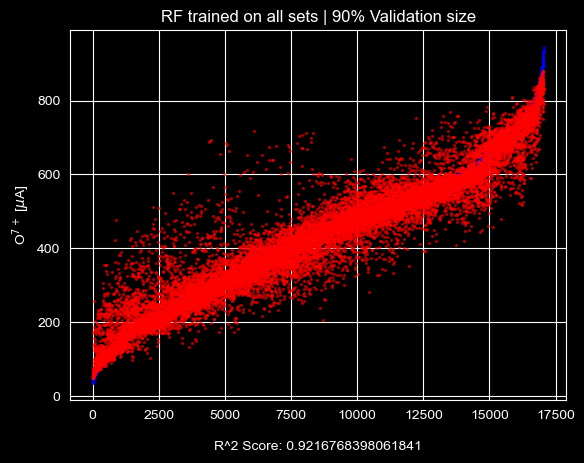

In [89]:

valY = valY.squeeze()
print(valY.shape, preds.shape)
indices = np.argsort(valY)
plt.scatter(range(len(valY)), 1e6*valY[indices], color='blue', alpha=0.5, s=2)
plt.scatter(range(len(valY)), 1e6*preds[indices], color='red', alpha=0.5, s=2)
plt.title("RF trained on all sets | 90% Validation size")
plt.ylabel("O$^{7+}$ [$\mu$A]")
plt.xlabel(f'\nR^2 Score: {r2}')
plt.savefig("presentation_plots/allsets_rf.png")
plt.show()